In [1]:
import pandas as pd
df = pd.read_csv('data/insurance.csv')


In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# We don't need to drop any columns as they are all important.
# df.drop([''], axis=1, inplace=True)

In [5]:
dtypes = df.dtypes
n_unique = df.nunique()
pd.DataFrame({'dtypes': dtypes, 'n_unique': n_unique}).T

,age,sex,bmi,children,smoker,region,charges
dtypes,int64,str,float64,int64,str,str,float64
n_unique,47,2,548,6,2,4,1337


In [6]:
cols = ['sex', 'children', 'smoker', 'region']
df[cols] = df[cols].astype('category')
pd.DataFrame({'dtypes': df.dtypes}).T

,age,sex,bmi,children,smoker,region,charges
dtypes,int64,category,float64,category,category,category,float64


In [7]:
null = df.isnull().sum()
ratio = null / df.shape[0] * 100
pd.DataFrame({"null": null, "ratio": ratio}).T

,age,sex,bmi,children,smoker,region,charges
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
#As there is no null values, we don't have to drop any column (drop) or drop any null values (dropna) or fill any null values (fillna).


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

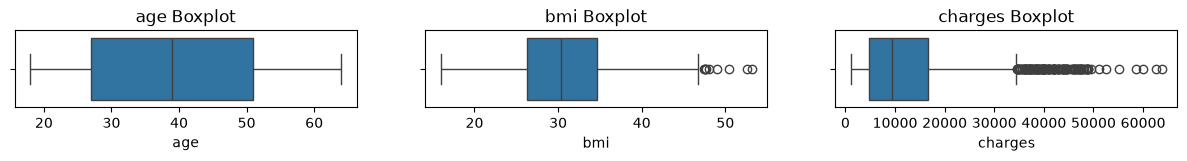

In [21]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(5*len(num_cols),1))

for i,col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} Boxplot")


In [30]:
col = 'bmi'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3-Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_outliers = df[df[col]<lower_fence][col].values
upper_outliers = df[df[col]>upper_fence][col].values
df[col] = df[col].replace(lower_outliers,lower_fence)
df[col] = df[col].replace(upper_outliers,upper_fence)

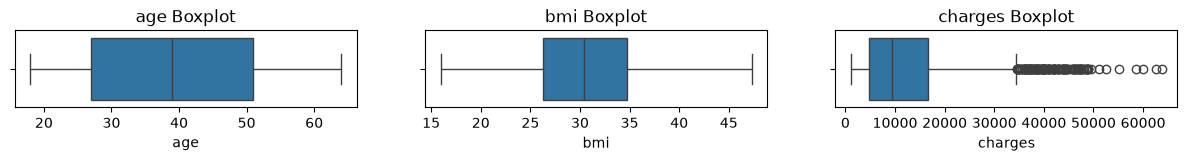

In [31]:
plt.figure(figsize=(5*len(num_cols),1))

for i,col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} Boxplot")

In [33]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [34]:
df.duplicated().sum()

np.int64(0)

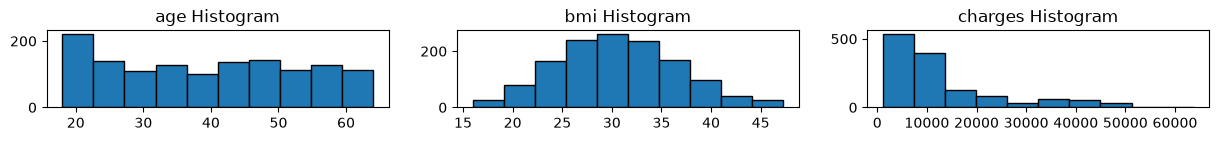

In [36]:
plt.figure(figsize=(5*len(num_cols),1))
for i,col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    plt.hist(df[col],edgecolor='black')
    plt.title(f"{col} Histogram")

Index(['sex', 'children', 'smoker', 'region'], dtype='str')


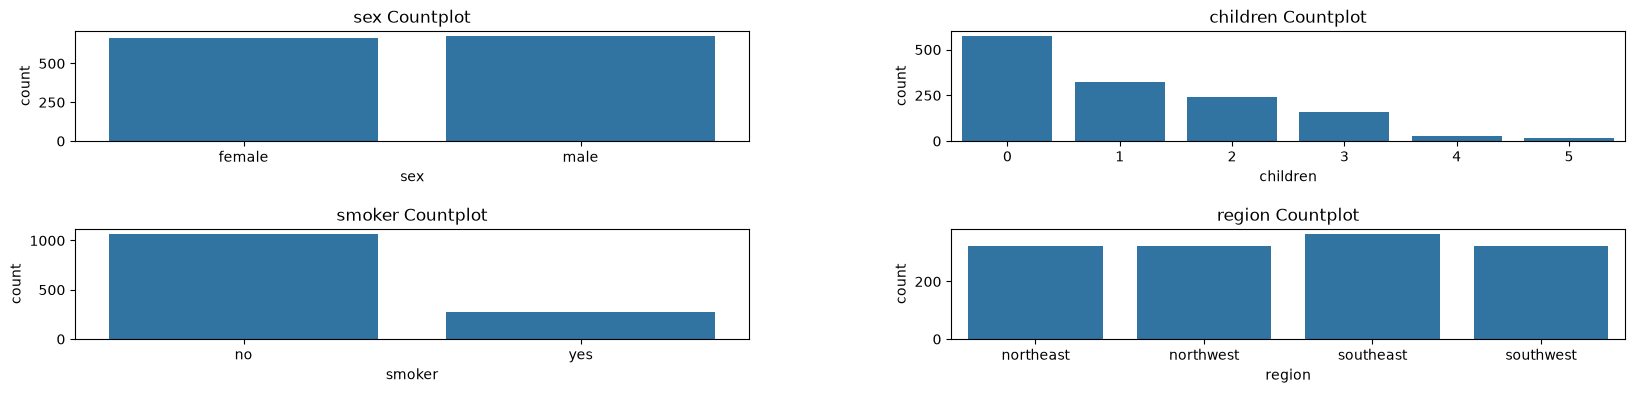

In [51]:
cat_cols = df.select_dtypes("category").columns
print(cat_cols)
plt.figure(figsize=(5*len(cat_cols),4))
for i,col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(x=col,data=df)
    plt.title(f"{col} Countplot")
plt.subplots_adjust(hspace=0.8,wspace=0.3)



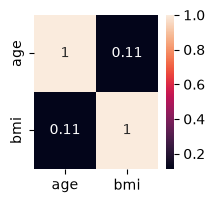

In [55]:
corr = df[['age','bmi']].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)
plt.show()

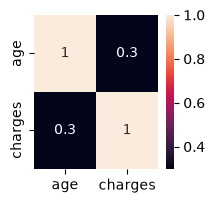

In [56]:
corr = df[['age','charges']].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)
plt.show()

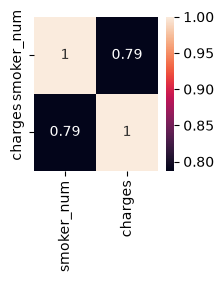

In [60]:
df['smoker_num'] = df['smoker'].map({'no': 0, 'yes': 1})
corr = df[['smoker_num','charges']].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)
plt.show()
df.drop(columns='smoker_num',inplace=True)

In [61]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
